Accuracy: 0.9649122807017544


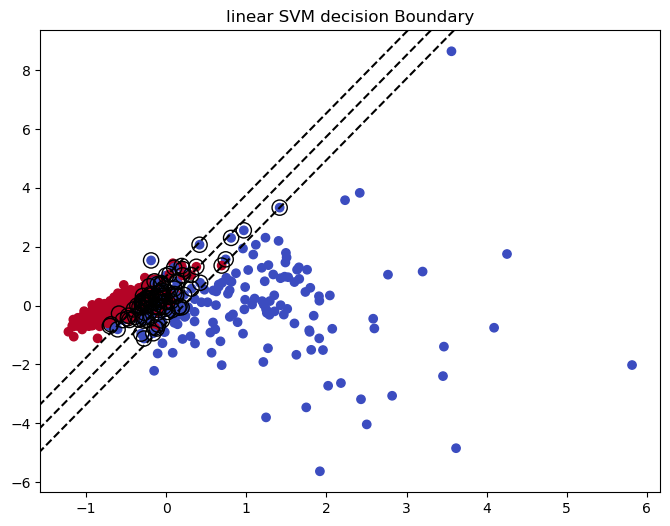

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
data=load_breast_cancer()
x=data.data
y=data.target
pca=PCA(n_components=2)
x=pca.fit_transform(x)

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()

x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

model=SVC(kernel="linear",C=1)

model.fit(x_train,y_train)

y_pred=model.predict(x_test)
acc=accuracy_score(y_test,y_pred)
print("Accuracy:",acc)
def plot_svm(model,x,y):
    plt.figure(figsize=(8,6))
    plt.scatter(x[:,0],x[:,1],c=y,cmap="coolwarm")
    ax=plt.gca()
    xlim=ax.get_xlim()
    ylim=ax.get_ylim()
    xx=np.linspace(xlim[0],xlim[1],100)
    yy=np.linspace(ylim[0],ylim[1],100)
    YY,XX=np.meshgrid(yy,xx)
    xy=np.stack([XX.ravel(),YY.ravel()]).T

    Z=model.decision_function(xy)
    Z=Z.reshape(XX.shape)

    ax.contour(XX,YY,Z,levels=[0],colors="black",linestyles="dashed")

    ax.contour(XX,YY,Z,levels=[-1,1],colors="black",linestyles="dashed")

    ax.scatter(
        model.support_vectors_[:,0],
        model.support_vectors_[:,1],
        s=120,
        facecolors="none",
        edgecolors="black"
    )

    plt.title("linear SVM decision Boundary")
    plt.show()

plot_svm(model,x_train,y_train)